In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("../PA1/imputed_data.csv")

## Section 1

In [6]:
# constructing the categorical comorbidity variable
comorbidity_columns = ['diabetes', 'hypertension', 'COPD', 'PVD', 'CKD', 'IHD', 'AF', 'VHD', 'PHTN']
data['n_comorbidities'] = data[comorbidity_columns].sum(axis=1)
data['cat_comorbidities'] = pd.cut(data['n_comorbidities'], bins=[0, 1, 3, np.inf], include_lowest=True, labels=['0-1', '2-3', '4+'])

In [14]:
# fit cox prop hazard model

from lifelines import CoxPHFitter

cph = CoxPHFitter()
formula = ("gender_0male_1female + age_YEARS + C(cat_comorbidities) + "
           "length_of_stay_DAYS + BUN_discharge + creatinine_discharge + GFR_discharge + "
           "BNP + WBC + sodium + RDW + platelets + bilirubin + potassium")
cph.fit(data, 
             duration_col='time_discharge_to_death_MONTHS', 
             event_col='death', 
             formula=formula)
cph.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]].round(4).sort_values(by="p")

,exp(coef),exp(coef) lower 95%,exp(coef) upper 95%,p
covariate,,,,
age_YEARS,1.0429,1.0373,1.0485,0.0000
BUN_discharge,1.0157,1.0127,1.0188,0.0000
sodium,0.9712,0.9611,0.9813,0.0000
BNP,1.0002,1.0001,1.0002,0.0000
RDW,1.1304,1.1004,1.1613,0.0000
length_of_stay_DAYS,1.0106,1.0049,1.0164,0.0003
bilirubin,1.1305,1.0143,1.2599,0.0266
platelets,1.0003,0.9998,1.0009,0.2003
potassium,0.9483,0.8721,1.0313,0.2150


The main findings are that age, BUN (at discharge), sodium, BNP, RDW, bilirubin and length of stay are significant predictors of mortality, with RDW and bilirubin having the strongest effects as they increase the risk of mortality by 13% times for each unit increase. The other variables have a smaller effect on mortality.

Another important finding is that the number of comorbidities is not a significant predictor of mortality in any level (with 0-1 as refrence level, 2-3 and 4+ are not significant). This suggests that the presence of comorbidities alone may not be a strong predictor of mortality, and that other factors such as age and lab values may be more important in determining mortality risk.

## Section 2

In [18]:
cph.log_likelihood_ratio_test()

<lifelines.StatisticalResult: log-likelihood ratio test>
null_distribution = chi squared
  degrees_freedom = 15
        test_name = log-likelihood ratio test

---
 test_statistic      p  -log2(p)
         731.35 <0.005    483.05

The likelihood ratio test comes out significant, so we reject the null hypothesis that all coefficients are equal to zero. This means that at least one of the covariates is significantly associated with the hazard of mortality.

## Section 3

In [19]:
data['delta_BUN'] = data['BUN_discharge'] - data['BUN_admission']

### (a)

In [21]:
data['delta_BUN'].describe()

count    3961.000000
mean        3.124383
std        14.898313
min       -83.000000
25%        -3.000000
50%         3.000000
75%         9.800000
max       208.300000
Name: delta_BUN, dtype: float64

<Axes: >

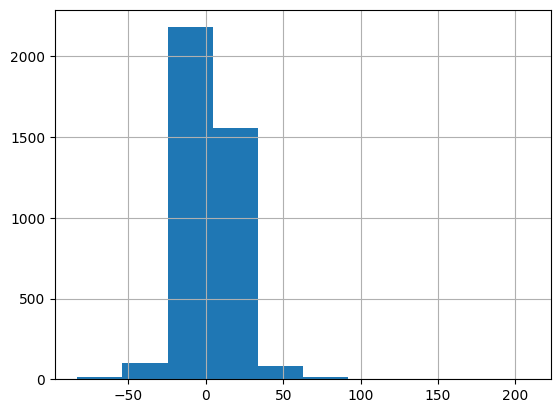

In [22]:
data['delta_BUN'].hist()

### (b)

BUN is the amount of urea nitrogen in the blood, which is a waste product from protein digestion. High BUN levels can indicate kidney dysfunction or dehydration, which can increase the risk of mortality. Low BUN levels are less common and usually not serious. Positive delta_BUN values indicate an increase in BUN levels from admission to discharge, which may suggest worsening kidney function or dehydration during hospitalization. Negative delta_BUN values indicate a decrease in BUN levels, which may suggest improvement in kidney function or hydration status.

### (c)

In [23]:
bun_cph = CoxPHFitter()
bun_formula = formula + " + delta_BUN"
bun_cph.fit(data, 
             duration_col='time_discharge_to_death_MONTHS', 
             event_col='death', 
             formula=bun_formula)

<lifelines.CoxPHFitter: fitted with 3961 total observations, 2282 right-censored observations>

### (d)

$H_0: \beta_{\text{delta\_BUN}} = 0$: The coefficient of delta_BUN is equal to zero (no effect on mortality)

$H_1: \beta_{\text{delta\_BUN}} \neq 0$: The coefficient of delta_BUN is not equal to zero (has an effect on mortality)

In [ ]:
from scipy import stats

lr = 2 * (bun_cph.log_likelihood_ - cph.log_likelihood_)
lr_pv = 1 - stats.chi2.cdf(lr, df=1)

print(f"Full log-likelihood: {bun_cph.log_likelihood_:.4f}")
print(f"Reduced log-likelihood: {cph.log_likelihood_:.4f}")
print(f"LR statistic: {lr:.4f}")
print(f"Degrees of freedom: 1")
print(f"p-value: {lr_pv:.4g}")

Full log-likelihood: -12896.5511
Reduced log-likelihood: -12910.3640
LR statistic: 27.6257
Degrees of freedom: 1
p-value: 1.472e-07


The likelihood ratio test comes out significant, so we reject the null hypothesis that the coefficient of delta_BUN is equal to zero. This means that delta_BUN is significantly associated with the hazard of mortality, and that changes in BUN levels from admission to discharge may be an important predictor of mortality risk. Therefore we should include it in our analysis.

### (e)

As the likelihood ratio test came out significant, it means that the change in BUN during hospitalization provides prognostic information beyond the patient’s condition at discharge.

## Section 4

In [60]:
s = bun_cph.baseline_survival_
s[s.index <= 12].values[-1]

array([0.78418695])

This is the one-year baseline survival probability, obtained by taking the exponential of the negative of the baseline cumulative hazard at 12 months. The  baseline cumulative hazard is obtained from Breslow estimator:
$$\hat{H}_0(t) = \sum_{i: Y_i \le t} \frac{1}{\sum_{j \in R(Y_i)} e^{\hat{\beta}^T x_j}}$$

So the baseline survival probability at 12 months is:
$$\hat{S}_0(12) = e^{-\hat{H}_0(12)}$$

In [71]:
def baseline_x(data):
    baseline = {}
    for col in data.columns:
        if pd.api.types.is_numeric_dtype(data[col]):
            baseline[col] = [data[col].median()]   # median, not mean
        else:
            baseline[col] = [data[col].mode().iloc[0]]
    return pd.DataFrame(baseline)


def cond_survival_prob(cph, t, x_df):
    """
    x_df: a 1-row DataFrame in the ORIGINAL covariate space (not dummy-encoded).
    lifelines handles encoding internally via predict_log_partial_hazard.
    """
    # Breslow baseline survival at time t
    s0 = cph.baseline_survival_
    s0_at_t = s0[s0.index <= t].iloc[-1, 0]   # scalar

    # log partial hazard = X^T beta, correctly encoded by lifelines
    log_ph = cph.predict_log_partial_hazard(x_df).values[0]   # scalar

    return s0_at_t ** np.exp(log_ph)


def plot_survival_by_covariate(cph, data, covariate, t=12.0, values=None):
    base = baseline_x(data)   # 1-row DataFrame

    if values is None:
        if pd.api.types.is_numeric_dtype(data[covariate]):
            values = np.linspace(data[covariate].min(), data[covariate].max(), 100)
        else:
            values = data[covariate].unique()
    values = np.sort(values)

    probs = []
    for v in values:
        x = base.copy()
        x[covariate] = v
        probs.append(cond_survival_prob(cph, t, x))

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(values, probs)
    ax.set_xlabel(covariate)
    ax.set_ylabel(f"Estimated {t}-month survival probability")
    ax.set_title(f"{t}-month survival by {covariate}\n(all other covariates at median/mode)")
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()

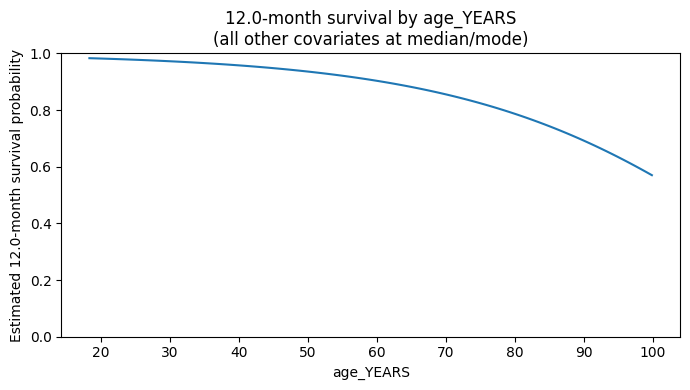

In [72]:
plot_survival_by_covariate(bun_cph, data, 'age_YEARS', t=12.0)

The age of the patient has a modest negative effect on the one-year survival probability, with older patients having a lower probability of surviving one year. The effect is not very strong, as it decline steadily from 1 to 0.8.

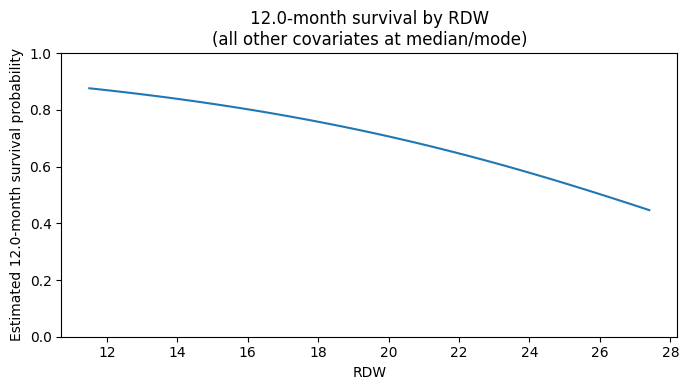

In [73]:
plot_survival_by_covariate(bun_cph, data, 'RDW', t=12.0)

RDW also has a somewhat modest negative effect, but with a steeper decline in survival probability as RDW increases. The effect is more pronounced than age, with survival probability dropping from 0.9 to 0.5 as RDW increases.

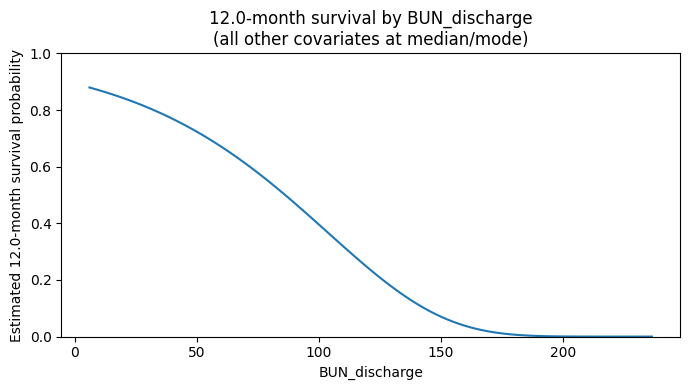

In [74]:
plot_survival_by_covariate(bun_cph, data, 'BUN_discharge', t=12.0)

The BUN at discharge has a more interesting effect, with a sharp decline in survival probability as BUN increases. Extremely high BUN values (above 50) are associated with a very low probability of surviving one year, while lower BUN values (below 20) are associated with a high probability of survival. This suggests that BUN at discharge is a strong predictor of mortality risk, and that patients with high BUN levels may require closer monitoring and intervention to improve their chances of survival.